# Ride-hailing marketplace: exploratory analysis

What the generated dataset contains, and whether its economics hold together.

This is the working record behind the findings in the README. It reads from the
same PostgreSQL database the assistant queries, so anything shown here is
something the assistant can be asked about.

Three questions drive it:

1. Does the funnel behave like a marketplace, or like independent coin flips?
2. Does surge respond to the supply/demand balance, as the brief requires?
3. Is there anything here that a careless analysis would get **wrong**?

The third turns out to be the interesting one.

**Prerequisites:** `make db-up && make reset`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.database.connection import get_engine

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

ENGINE = get_engine(readonly=True)


def query(sql: str, **parameters) -> pd.DataFrame:
    """Run a read-only query and return a DataFrame."""
    with ENGINE.connect() as connection:
        return pd.read_sql(sql, connection, params=parameters or None)


query("""
    SELECT COUNT(*)                 AS calculated_rides,
           COUNT(DISTINCT user_id)  AS riders,
           MIN(calculated_at)::date AS first_day,
           MAX(calculated_at)::date AS last_day
    FROM rides
""")

,calculated_rides,riders,first_day,last_day
0,673199,9998,2026-01-05,2026-03-05


## 1. The funnel

Every row in `rides` is one price calculation. Two decisions follow it: the rider
either places the order or abandons it, and a driver either accepts it or does not.

Rates have to be computed from summed counts, not averaged across groups — the
usual way funnel numbers go wrong.

In [2]:
funnel = query("""
    SELECT COUNT(*)                                      AS calculated,
           SUM(placed::int)                              AS placed,
           SUM(accepted::int)                            AS accepted,
           SUM(placed::int)::float / COUNT(*)            AS place_conversion,
           SUM(accepted::int)::float / SUM(placed::int)  AS acceptance_rate,
           SUM(accepted::int)::float / COUNT(*)          AS end_to_end
    FROM rides
""").iloc[0]

print(f"calculated  {funnel.calculated:>8,.0f}")
print(f"placed      {funnel.placed:>8,.0f}   {funnel.place_conversion:.1%} of calculated  (rider's decision)")
print(f"accepted    {funnel.accepted:>8,.0f}   {funnel.acceptance_rate:.1%} of placed      (driver's decision)")
print(f"\nend-to-end conversion: {funnel.end_to_end:.1%}")

calculated   673,199
placed       407,536   60.5% of calculated  (rider's decision)
accepted     348,238   85.4% of placed      (driver's decision)

end-to-end conversion: 51.7%


## 2. The shape of the day

The first thing to check, because it determines whether any hourly average in this
dataset can be read at face value.

Note what `is_curfew_hour` does to the picture. Between 00:00 and 05:00 civilian
movement is prohibited, so the overnight trough is a legal restriction rather than
weak consumer demand. Averaging across it, or ranking hours without excluding it,
produces a confident and wrong story.

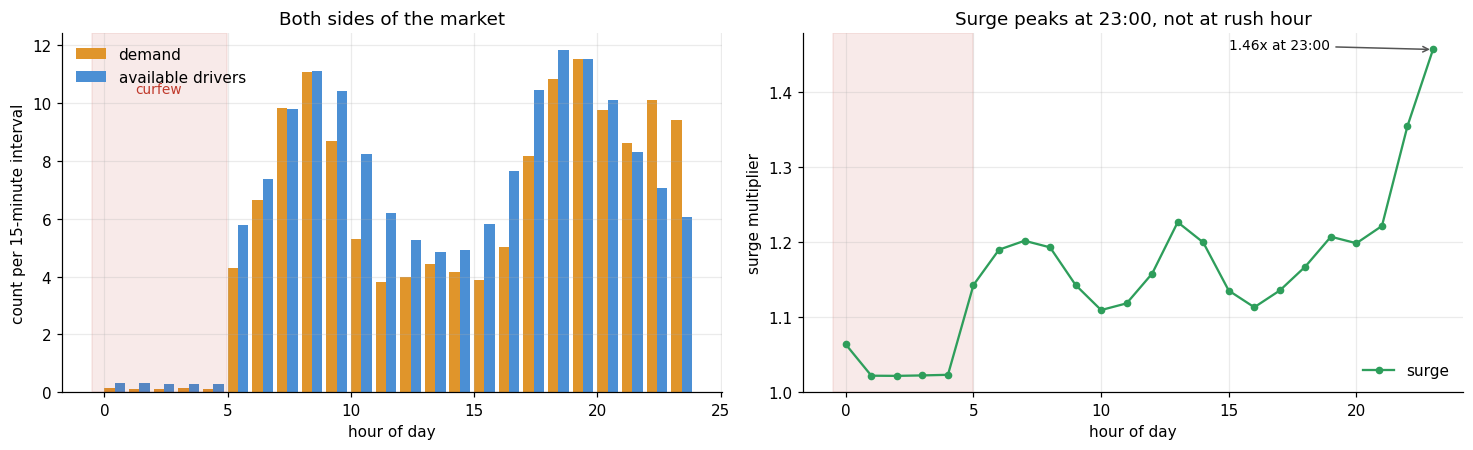

quietest non-curfew hour : 11:00  (3.8 demand)
busiest hour             : 19:00  (11.5 demand)
curfew hours             : 0.16 demand at most


In [3]:
hourly = query("""
    SELECT hour,
           BOOL_OR(curfew)            AS is_curfew_hour,
           AVG(demand_count)          AS demand,
           AVG(available_drivers)     AS drivers,
           AVG(demand_supply_ratio)   AS ratio,
           AVG(surge_multiplier)      AS surge,
           AVG(average_eta_minutes)   AS eta
    FROM zone_state
    GROUP BY hour
    ORDER BY hour
""")

figure, (left, right) = plt.subplots(1, 2, figsize=(13.5, 4.2))

left.bar(hourly.hour, hourly.demand, label="demand", color="#e0952b", width=0.42, align="edge")
left.bar(hourly.hour + 0.42, hourly.drivers, label="available drivers", color="#4b8fd4", width=0.42, align="edge")
left.axvspan(-0.5, 4.98, color="#c0392b", alpha=0.10)
left.text(2.2, hourly.demand.max() * 0.9, "curfew", ha="center", color="#c0392b", fontsize=9)
left.set(xlabel="hour of day", ylabel="count per 15-minute interval", title="Both sides of the market")
left.legend(frameon=False)

right.plot(hourly.hour, hourly.surge, marker="o", ms=4, color="#2e9e5b", label="surge")
right.axvspan(-0.5, 4.98, color="#c0392b", alpha=0.10)
right.set(xlabel="hour of day", ylabel="surge multiplier", title="Surge peaks at 23:00, not at rush hour")
right.legend(frameon=False)

peak = hourly[~hourly.is_curfew_hour].nlargest(1, "surge").iloc[0]
right.annotate(
    f"{peak.surge:.2f}x at {int(peak.hour)}:00",
    xy=(peak.hour, peak.surge),
    xytext=(peak.hour - 8, peak.surge),
    arrowprops={"arrowstyle": "->", "color": "#555"},
    fontsize=9,
)

plt.tight_layout()
plt.show()

awake = hourly[~hourly.is_curfew_hour]
print(f"quietest non-curfew hour : {int(awake.nsmallest(1, 'demand').iloc[0].hour):>2}:00  ({awake.demand.min():.1f} demand)")
print(f"busiest hour             : {int(awake.nlargest(1, 'demand').iloc[0].hour):>2}:00  ({awake.demand.max():.1f} demand)")
print(f"curfew hours             : {hourly[hourly.is_curfew_hour].demand.max():.2f} demand at most")

### Why 23:00 and not 19:00

The surge peak is not a demand spike. Demand at 23:00 is *below* the evening peak.
What collapses is supply: drivers go offline ahead of the curfew faster than riders
stop requesting rides.

This is the mechanism the brief asks for — surge rising when demand outstrips
available drivers — arriving through the supply side rather than the demand side.

In [4]:
comparison = hourly.set_index("hour").loc[[19, 22, 23], ["demand", "drivers", "ratio", "surge", "eta"]]
comparison.index = ["19:00 evening commute", "22:00 pre-curfew", "23:00 pre-curfew"]
display(comparison.round(2))

print(
    f"\nFrom 19:00 to 23:00 demand falls {1 - hourly.loc[23, 'demand'] / hourly.loc[19, 'demand']:.0%} "
    f"while drivers fall {1 - hourly.loc[23, 'drivers'] / hourly.loc[19, 'drivers']:.0%}."
    "\nThe supply side moves further, so the ratio rises and surge follows."
)

,demand,drivers,ratio,surge,eta
19:00 evening commute,11.52,11.53,1.26,1.21,9.50
22:00 pre-curfew,10.10,7.07,1.67,1.35,10.34
23:00 pre-curfew,9.41,6.05,1.84,1.46,10.98



From 19:00 to 23:00 demand falls 18% while drivers fall 47%.
The supply side moves further, so the ratio rises and surge follows.


## 3. Surge responds to the supply/demand balance

The core requirement from the brief, checked directly: bin every zone-interval by
its demand/supply ratio and look at what surge and ETA do.

Curfew intervals are excluded, since almost nothing is being requested then and
surge is meaningless.

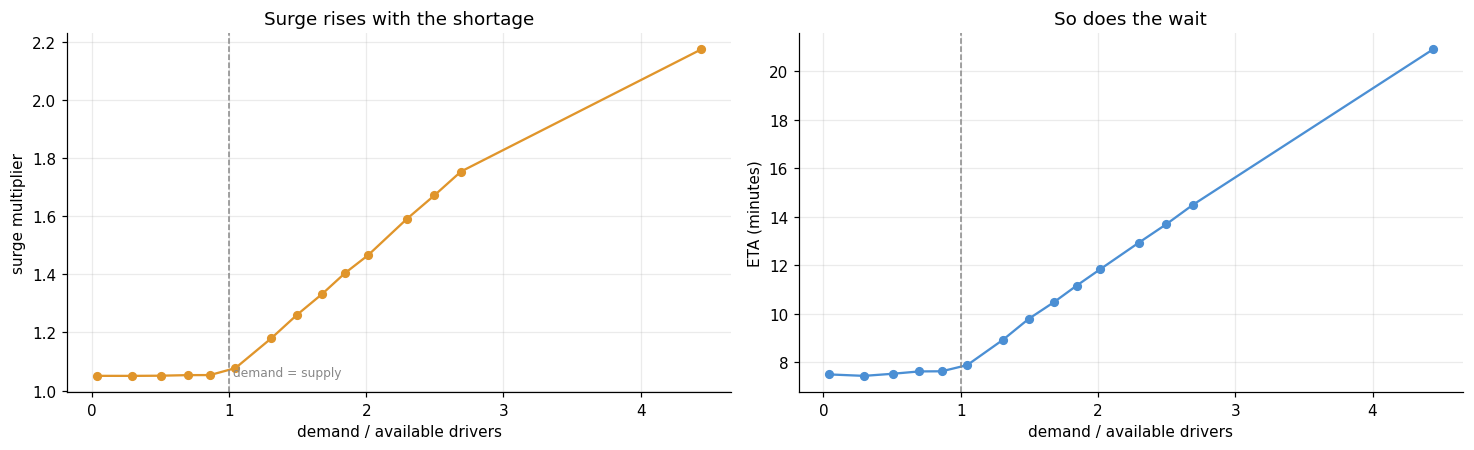

  ratio_vs_surge   r = +0.830
  ratio_vs_eta     r = +0.820
  surge_vs_eta     r = +0.843


In [5]:
by_ratio = query("""
    SELECT WIDTH_BUCKET(demand_supply_ratio, 0, 3, 15) AS bucket,
           AVG(demand_supply_ratio)                    AS ratio,
           AVG(surge_multiplier)                       AS surge,
           AVG(average_eta_minutes)                    AS eta,
           COUNT(*)                                    AS intervals
    FROM zone_state
    WHERE NOT curfew
    GROUP BY bucket
    HAVING COUNT(*) > 200
    ORDER BY bucket
""")

figure, (left, right) = plt.subplots(1, 2, figsize=(13.5, 4.2))

left.plot(by_ratio.ratio, by_ratio.surge, marker="o", ms=5, color="#e0952b")
left.set(xlabel="demand / available drivers", ylabel="surge multiplier",
         title="Surge rises with the shortage")
left.axvline(1.0, ls="--", lw=1, color="#888")
left.text(1.03, by_ratio.surge.min(), "demand = supply", fontsize=8, color="#888")

right.plot(by_ratio.ratio, by_ratio.eta, marker="o", ms=5, color="#4b8fd4")
right.set(xlabel="demand / available drivers", ylabel="ETA (minutes)",
          title="So does the wait")
right.axvline(1.0, ls="--", lw=1, color="#888")

plt.tight_layout()
plt.show()

correlations = query("""
    SELECT CORR(demand_supply_ratio, surge_multiplier)     AS ratio_vs_surge,
           CORR(demand_supply_ratio, average_eta_minutes)  AS ratio_vs_eta,
           CORR(surge_multiplier, average_eta_minutes)     AS surge_vs_eta
    FROM zone_state
    WHERE NOT curfew
""").iloc[0]

for name, value in correlations.items():
    print(f"  {name:<16} r = {value:+.3f}")

## 4. ETA and conversion

One of the questions from the brief. The relationship is strong at the ordering
stage and much weaker at acceptance, which makes sense: the rider is the one
waiting.

Note that `surge_vs_eta` above is high. That matters in the next section.

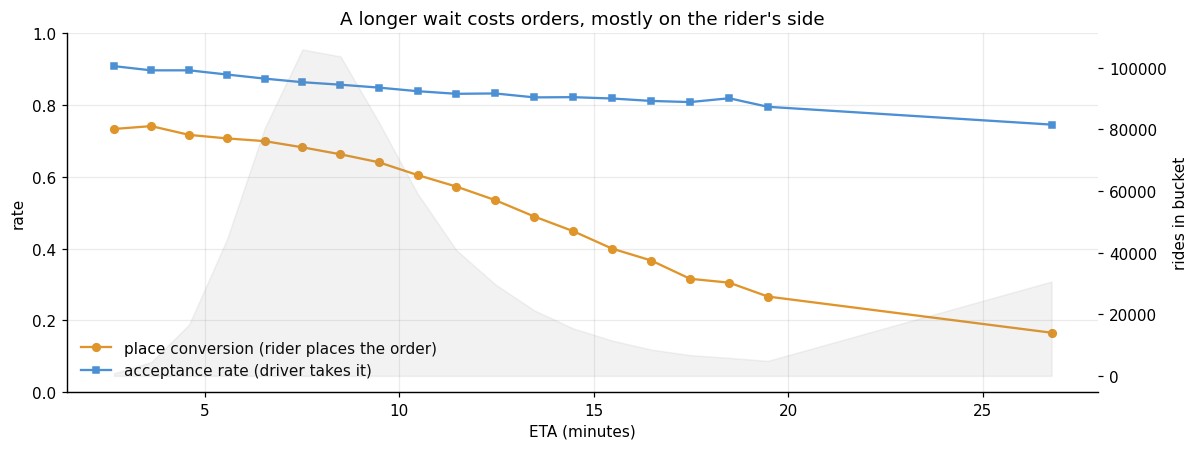

place conversion  73.3% -> 16.6%   (57% drop)
acceptance rate   90.8% -> 74.5%   (16% drop)


In [6]:
by_eta = query("""
    SELECT WIDTH_BUCKET(eta_minutes, 0, 20, 20)          AS bucket,
           AVG(eta_minutes)                              AS eta,
           AVG(placed::float)                             AS place_conversion,
           AVG(accepted::float) FILTER (WHERE placed = 1) AS acceptance_rate,
           COUNT(*)                                      AS rides
    FROM rides
    GROUP BY bucket
    HAVING COUNT(*) > 500
    ORDER BY bucket
""")

figure, axis = plt.subplots(figsize=(11, 4.2))

axis.plot(by_eta.eta, by_eta.place_conversion, marker="o", ms=5,
          color="#e0952b", label="place conversion (rider places the order)")
axis.plot(by_eta.eta, by_eta.acceptance_rate, marker="s", ms=4,
          color="#4b8fd4", label="acceptance rate (driver takes it)")
axis.set(xlabel="ETA (minutes)", ylabel="rate", ylim=(0, 1),
         title="A longer wait costs orders, mostly on the rider's side")
axis.legend(frameon=False, loc="lower left")

volume = axis.twinx()
volume.fill_between(by_eta.eta, by_eta.rides, color="#888", alpha=0.10)
volume.set_ylabel("rides in bucket")
volume.grid(False)

plt.tight_layout()
plt.show()

span = by_eta.iloc[[0, -1]]
print(
    f"place conversion  {span.place_conversion.iloc[0]:.1%} -> {span.place_conversion.iloc[-1]:.1%}"
    f"   ({span.place_conversion.iloc[0] - span.place_conversion.iloc[-1]:.0%} drop)"
)
print(
    f"acceptance rate   {span.acceptance_rate.iloc[0]:.1%} -> {span.acceptance_rate.iloc[-1]:.1%}"
    f"   ({span.acceptance_rate.iloc[0] - span.acceptance_rate.iloc[-1]:.0%} drop)"
)

## 5. The trap: does surge deter drivers?

The obvious query is a cross-tab of acceptance rate by surge bucket. Run it and
surge looks mildly harmful — acceptance drifts *down* as surge goes up.

That conclusion is wrong, and acting on it would mean removing the incentive that
is actually recruiting drivers into shortages.

In [7]:
SURGE_BUCKET = """
    CASE WHEN surge_multiplier <= 1.05 THEN '1.00-1.05'
         WHEN surge_multiplier <= 1.20 THEN '1.05-1.20'
         WHEN surge_multiplier <= 1.50 THEN '1.20-1.50'
         ELSE '1.50+' END
"""

marginal = query(f"""
    SELECT {SURGE_BUCKET}                 AS surge_bucket,
           AVG(accepted::float)           AS acceptance_rate,
           COUNT(*)                       AS orders
    FROM rides
    WHERE placed = 1
    GROUP BY surge_bucket
    ORDER BY surge_bucket
""")

print("The naive answer:\n")
print(marginal.to_string(index=False, formatters={"acceptance_rate": "{:.1%}".format}))
print(
    f"\nAcceptance falls from {marginal.acceptance_rate.iloc[0]:.1%} to "
    f"{marginal.acceptance_rate.iloc[-1]:.1%} as surge rises. Surge appears to hurt."
)

The naive answer:

surge_bucket acceptance_rate  orders
   1.00-1.05           85.6%  161157
   1.05-1.20           85.7%  129038
   1.20-1.50           85.1%   78183
       1.50+           84.5%   39158

Acceptance falls from 85.6% to 84.5% as surge rises. Surge appears to hurt.


### Why it is wrong

Surge and ETA both rise when drivers are scarce, so they are strongly correlated.
The comparison above is therefore not "same trip, more money" — it silently
contrasts *short pickups at low surge* against *long pickups at high surge*, and the
pickup distance is what drivers are actually refusing.

Hold ETA fixed and the relationship reverses.

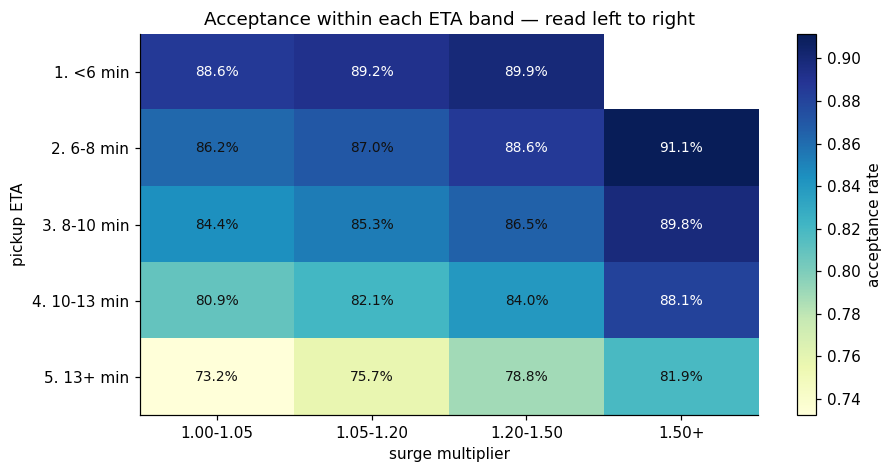

Within a fixed ETA band, acceptance rises with surge:

  1. <6 min     88.6% -> 89.9%   rises
  2. 6-8 min    86.2% -> 91.1%   rises
  3. 8-10 min   84.4% -> 89.8%   rises
  4. 10-13 min  80.9% -> 88.1%   rises
  5. 13+ min    73.2% -> 81.9%   rises


In [8]:
conditional = query(f"""
    SELECT CASE WHEN eta_minutes <=  6 THEN '1. <6 min'
                WHEN eta_minutes <=  8 THEN '2. 6-8 min'
                WHEN eta_minutes <= 10 THEN '3. 8-10 min'
                WHEN eta_minutes <= 13 THEN '4. 10-13 min'
                ELSE                       '5. 13+ min' END  AS eta_band,
           {SURGE_BUCKET}                                    AS surge_bucket,
           AVG(accepted::float)                              AS acceptance_rate,
           COUNT(*)                                          AS orders
    FROM rides
    WHERE placed = 1
    GROUP BY eta_band, surge_bucket
    HAVING COUNT(*) >= 200
    ORDER BY eta_band, surge_bucket
""")

grid = conditional.pivot(index="eta_band", columns="surge_bucket", values="acceptance_rate")

figure, axis = plt.subplots(figsize=(8.5, 4.4))
image = axis.imshow(grid.values, cmap="YlGnBu", aspect="auto")

axis.set_xticks(range(len(grid.columns)), grid.columns)
axis.set_yticks(range(len(grid.index)), grid.index)
axis.set(xlabel="surge multiplier", ylabel="pickup ETA",
         title="Acceptance within each ETA band — read left to right")
axis.grid(False)

for row in range(grid.shape[0]):
    for column in range(grid.shape[1]):
        value = grid.values[row, column]
        if pd.notna(value):
            axis.text(column, row, f"{value:.1%}", ha="center", va="center",
                      fontsize=9, color="#111" if value < 0.87 else "#fff")

figure.colorbar(image, label="acceptance rate")
plt.tight_layout()
plt.show()

print("Within a fixed ETA band, acceptance rises with surge:\n")
for band, row in grid.iterrows():
    usable = row.dropna()
    if len(usable) >= 2:
        direction = "rises" if usable.iloc[-1] > usable.iloc[0] else "falls"
        print(f"  {band:<13} {usable.iloc[0]:.1%} -> {usable.iloc[-1]:.1%}   {direction}")

Simpson's paradox, in a dataset a pricing team would plausibly be looking at. Every
row reverses the aggregate.

This is why `acceptance_confounding` exists as a dedicated tool rather than leaving
the assistant to write the cross-tab itself: the prompt names the trap and points
at the tool, so the answer reports both views and explains the difference.

## 6. Clustering

The last question from the brief. Zones are clustered on eleven behavioural
features — demand, driver availability, surge, ETA, conversion, price, distance,
peak-hour and weekend shares. **`zone_type` is deliberately not an input**, so any
alignment with it is a result rather than an assumption.

In [9]:
from src.analytics.clustering import cluster_zones

result = cluster_zones()
assignments = pd.DataFrame(result["assignments"])

print(f"k = {result['number_of_clusters']} ({result['cluster_count_selection']})")
print(f"silhouette = {result['silhouette_score']}")
print(f"PC1 + PC2 explain {sum(result['explained_variance_ratio']):.0%} of variance\n")

crosstab = pd.crosstab(assignments.cluster, assignments.zone_type)
display(crosstab)

pure = (crosstab > 0).sum(axis=1).eq(1).sum()
print(f"\nClusters containing exactly one zone type: {pure} of {len(crosstab)}")
print("zone_type was never given to the model, so this is recovered from behaviour alone.")

k = 6 (chosen automatically by silhouette score)
silhouette = 0.4405
PC1 + PC2 explain 81% of variance



zone_type,business,city_center,entertainment,railway_station,residential,suburban
cluster,,,,,,
0,0,0,0,0,7,0
1,0,0,0,0,0,2
2,0,0,3,0,0,0
3,4,0,0,0,0,0
4,0,2,0,0,0,0
5,0,0,0,2,0,0



Clusters containing exactly one zone type: 6 of 6
zone_type was never given to the model, so this is recovered from behaviour alone.


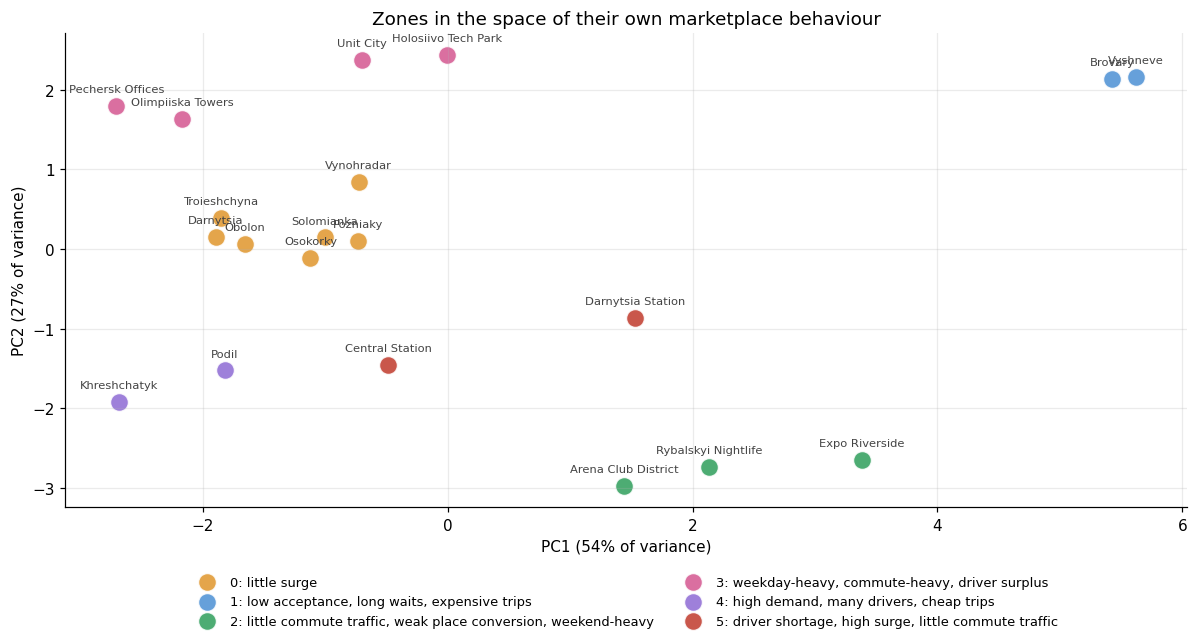

,members,average_demand,average_demand_supply_ratio,average_surge,average_eta_minutes,place_conversion,acceptance_rate
cluster,,,,,,,
0,7,6.606,0.815,1.115,8.253,0.623,0.856
1,2,2.616,1.078,1.247,10.606,0.482,0.764
2,3,4.924,1.094,1.249,8.832,0.484,0.870
3,4,4.263,0.727,1.121,8.484,0.624,0.858
4,2,11.133,0.881,1.112,8.719,0.633,0.855
5,2,5.654,1.081,1.209,8.866,0.629,0.861


In [10]:
chart = result["chart"]
points = pd.DataFrame({
    "x": chart["x"],
    "y": chart["y"],
    "zone": chart["labels"],
    "cluster": chart["clusters"],
})

figure, axis = plt.subplots(figsize=(11, 6))
palette = ["#e0952b", "#4b8fd4", "#2e9e5b", "#d4568f", "#8d6ad4", "#c0392b"]

for cluster, group in points.groupby("cluster"):
    axis.scatter(
        group.x, group.y, s=140, alpha=0.85,
        color=palette[cluster % len(palette)],
        edgecolor="white", linewidth=1,
        label=f"{cluster}: {chart['cluster_descriptions'][str(cluster)]}",
    )
    for _, point in group.iterrows():
        axis.annotate(point.zone, (point.x, point.y), fontsize=7.5,
                      xytext=(0, 9), textcoords="offset points", ha="center", color="#444")

axis.set(xlabel=chart["x_title"], ylabel=chart["y_title"],
         title="Zones in the space of their own marketplace behaviour")
axis.legend(frameon=False, fontsize=8.5, loc="upper center",
            bbox_to_anchor=(0.5, -0.12), ncol=2)

plt.tight_layout()
plt.show()

profiles = pd.DataFrame(result["cluster_profiles"]).set_index("cluster")
display(
    profiles[["members", "average_demand", "average_demand_supply_ratio", "average_surge",
              "average_eta_minutes", "place_conversion", "acceptance_rate"]].round(3)
)

## What this means for the assistant

Three things carried over into the design:

1. **The curfew has to be visible in the data, not just the prompt.** An hourly
   breakdown without an `is_curfew_hour` column led every model tested to
   recommend promotions during hours when movement is prohibited. Adding the column
   fixed it. Instructions compete for attention; a column in the result does not.

2. **The surge/acceptance question needs a dedicated tool.** Left to write its own
   cross-tab, a model reports the marginal number and gets the sign wrong. The tool
   computes both views, and the prompt tells the model to report both.

3. **Volume and rate are different questions.** 22:00–23:00 has among the highest
   demand of the day *and* the worst place conversion. "When is it busiest" is
   answered with counts; "where are we losing people" with rates. Conflating them
   turns the pre-curfew rush into a phantom quiet period.

The suburban pair — Brovary and Vyshneve — is the clearest actionable finding: the
longest waits, the highest prices and the worst driver acceptance in the city.

### Rider clustering, briefly

Reported more cautiously than the zone clustering, and worth seeing why.

In [11]:
from src.analytics.clustering import cluster_users

riders = cluster_users()

print(f"k = {riders['number_of_clusters']}, silhouette = {riders['silhouette_score']} "
      f"(zones: {result['silhouette_score']})\n")
display(pd.DataFrame(riders["assignments"]))

print("\nWhy k was not chosen by silhouette alone:")
display(pd.DataFrame(riders["silhouette_by_k"]))

print(
    "\nk=2 scores well and is useless: one cluster holds most of the base and is\n"
    "describable only as 'close to average'. The selection rule therefore rejects\n"
    "solutions where any cluster exceeds 45% of the population — a stated judgement,\n"
    "not a purely mechanical criterion.\n"
)
for caveat in riders["caveats"]:
    print(f"  - {caveat}")

k = 8, silhouette = 0.232 (zones: 0.4405)



,cluster,cluster_description,users,share_of_clustered_users
0,0,night traveller,531,0.0885
1,1,"frequent station trips, rarely starts in housi...",273,0.0455
2,2,starts trips at home,1973,0.3288
3,3,"morning traveller, starts trips at home, long ...",1145,0.1908
4,4,"suburban rider, expensive trips, long trips",232,0.0387
5,5,"starts trips in business districts, weekday-he...",491,0.0818
6,6,"starts trips in nightlife areas, travels when ...",381,0.0635
7,7,"starts trips downtown, rarely starts in housin...",974,0.1623



Why k was not chosen by silhouette alone:


,k,silhouette_score,largest_cluster_share,eligible
0,2,0.3595,0.8813,False
1,3,0.1949,0.5720,False
2,4,0.2245,0.5753,False
3,5,0.2468,0.6157,False
4,6,0.2788,0.5770,False
5,7,0.2292,0.3873,True
6,8,0.2320,0.3288,True



k=2 scores well and is useless: one cluster holds most of the base and is
describable only as 'close to average'. The selection rule therefore rejects
solutions where any cluster exceeds 45% of the population — a stated judgement,
not a purely mechanical criterion.

  - Only riders with at least 30 calculated rides are included, so these are not the whole user base.
  - Behavioural features only. The simulation's latent user traits are not stored in the database and were not used.
  - k is chosen by silhouette score among solutions where no cluster holds more than 45% of riders. Silhouette alone prefers k=2 here, which is geometrically clean but commercially useless: it leaves 88% of riders in one cluster sitting at the population average.
  - Rider segments overlap far more than zone types do. Treat these clusters as a description of behaviour, not as sharply separated groups.
